# 6. Rheology and Io

A body's tidal response depends on how its material deforms under a periodic load, which is set by its rheology. A rheology combines an elastic shear modulus and a viscosity into a complex shear modulus that depends on the forcing frequency, and the radial solver turns that into a complex Love number $k_2$. The imaginary part of $k_2$ sets the dissipation, so -Im($k_2$), times orbital factors, is the tidal heating.

Dissipation peaks when the material's Maxwell time (viscosity over shear modulus) is comparable to the tidal period. This notebook maps Io's tidal heating across shear modulus and viscosity for four rheologies, and swaps rheologies without rebuilding the planet.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G, M_jup
from TidalPy.RadialSolver_x import homogeneous_love_numbers
from TidalPy.rheology_x import Maxwell, Burgers, Andrade, Sundberg

# Io as a homogeneous sphere raised by Jupiter's tide.
R = 1.8216e6
M = 8.9319e22
RHO = M / (4.0 / 3.0 * np.pi * R**3)
A_IO = 4.217e8
E_IO = 0.0041
N_MOTION = np.sqrt(G * M_jup / A_IO**3)

# Only the complex shear modulus changes as we vary the rheology; the package helper
# builds the homogeneous grid and runs the solver.
SLICES = 60

def love_k2(shear, viscosity, rheology):
    "Complex tidal k2 for a homogeneous Io with the given shear modulus, viscosity, and rheology."
    complex_shear = rheology.calc_complex_modulus(shear, viscosity, N_MOTION)
    solution = homogeneous_love_numbers(R, RHO, complex_shear, N_MOTION, num_slices=SLICES)
    return complex(np.atleast_1d(solution.k)[0])

def heating(shear, viscosity, rheology, ecc=E_IO):
    "Tidal heating [W] from the leading e^2 term: (21/2) (-Im k2) G M_host^2 R^5 e^2 n / a^6."
    neg_im_k2 = -love_k2(shear, viscosity, rheology).imag
    return 10.5 * neg_im_k2 * G * M_jup**2 * R**5 * ecc**2 * N_MOTION / A_IO**6

# Swapping the rheology is just passing a different object; the planet is never rebuilt.
for name, rheo in [("Maxwell", Maxwell()), ("Andrade", Andrade(0.3, 1.0))]:
    print(f"{name:8}  k2 = {love_k2(60e9, 1e14, rheo):.4f}   heating = {heating(60e9, 1e14, rheo):.3e} W")

Maxwell   k2 = 0.1437-0.3932j   heating = 2.446e+15 W
Andrade   k2 = 0.1955-0.3880j   heating = 2.414e+15 W


## Heating Across Shear Modulus and Viscosity

For each of four rheologies the mantle shear modulus and viscosity are swept and the tidal heating mapped. The diagonal ridge in each panel is where the Maxwell time meets the tidal period. The transient terms in Andrade, Burgers, and Sundberg-Cooper broaden that ridge toward higher viscosity, so those rheologies dissipate over a wider range of conditions than a plain Maxwell body.

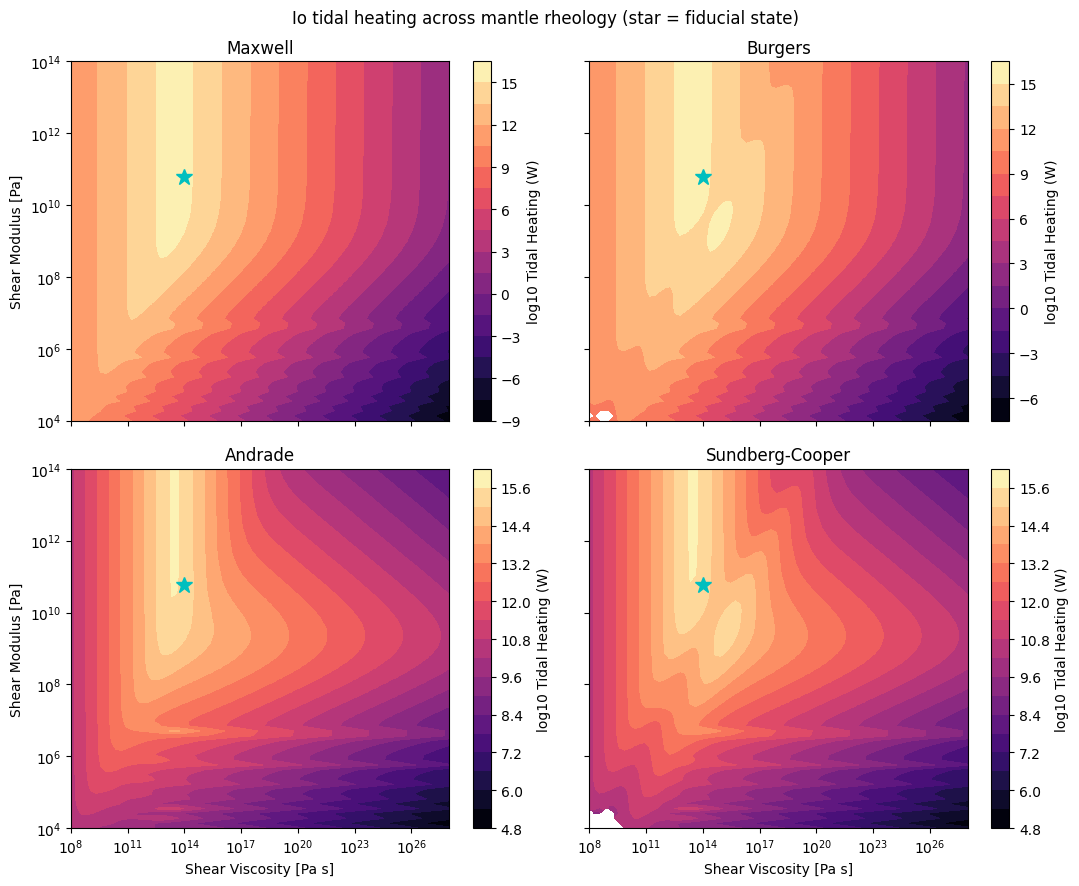

In [2]:
shear_axis = np.logspace(4, 14, 75)
visc_axis = np.logspace(8, 28, 76)
SH, VI = np.meshgrid(shear_axis, visc_axis)

rheologies = [
    ("Maxwell", Maxwell()),
    ("Burgers", Burgers(0.3, 0.05)),
    ("Andrade", Andrade(0.3, 1.0)),
    ("Sundberg-Cooper", Sundberg(0.3, 1.0, 0.2, 0.02)),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, (name, rheo) in zip(axes.ravel(), rheologies):
    grid = np.array([[heating(mu, eta, rheo) for mu in shear_axis] for eta in visc_axis])
    cf = ax.contourf(VI, SH, np.log10(grid), levels=20, cmap="magma")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(name)
    ax.plot(1.0e14, 60e9, "c*", ms=12)      # a fiducial mantle state
    fig.colorbar(cf, ax=ax, label="log10 Tidal Heating (W)")
for ax in axes[-1]:
    ax.set_xlabel("Shear Viscosity [Pa s]")
for ax in axes[:, 0]:
    ax.set_ylabel("Shear Modulus [Pa]")
fig.suptitle("Io tidal heating across mantle rheology (star = fiducial state)")
fig.tight_layout()
plt.show()


## Heating Versus Eccentricity Across Rheologies

At a fixed mantle state all four rheologies grow as roughly $e^2$ but differ in absolute level, because each converts the same forcing into a different amount of dissipation. The eccentricity range is the one Io is thought to have occupied (Hussmann & Spohn 2004).

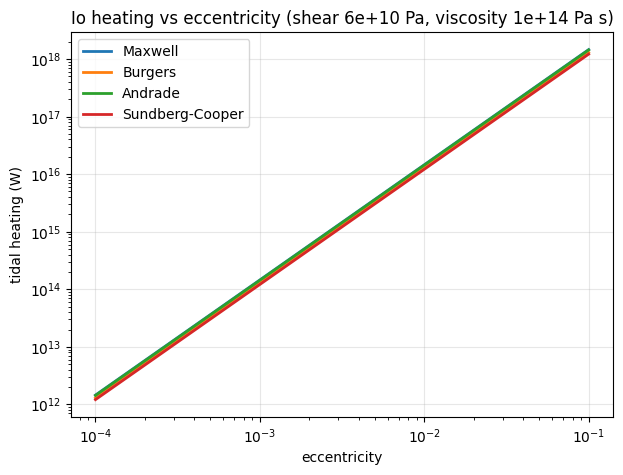

In [3]:
eccs = np.logspace(-4, -1, 60)
mu0, eta0 = 60.0e9, 1.0e14

fig, ax = plt.subplots(figsize=(7, 5))
for name, rheo in rheologies:
    curve = [heating(mu0, eta0, rheo, ecc=e) for e in eccs]
    ax.loglog(eccs, curve, lw=2, label=name)
ax.set_xlabel("eccentricity")
ax.set_ylabel("tidal heating (W)")
ax.set_title(f"Io heating vs eccentricity (shear {mu0:.0e} Pa, viscosity {eta0:.0e} Pa s)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()
